# EDA — Módulo 3: Sistema de recomendación de destinos de viaje

Análisis exploratorio del dataset de recomendación usado por el recomendador híbrido (filtrado colaborativo + contenido) del módulo 3.

- **Ubicación:** `data/raw/module3_recommender/`
- **Archivos:**
  - `Expanded_Destinations.csv` — catálogo de destinos (contenido).
  - `Final_Updated_Expanded_Reviews.csv` — reseñas usuario–destino con rating.
  - `Final_Updated_Expanded_UserHistory.csv` — historial de visitas con rating de experiencia.
  - `Final_Updated_Expanded_Users.csv` — perfiles de usuario.

Contenido del análisis: conteos generales, distribución de ratings, long-tail de interacciones por usuario, popularidad de destinos, sparsidad de la matriz usuario–destino, análisis de contenido y duplicidad de `DestinationID`. Las figuras y el resumen JSON se exportan a `docs/figures/module3_recommender/`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# Rutas relativas a la raiz del repo (el notebook vive en notebooks/)
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebooks" else NOTEBOOK_DIR
DATA_DIR = REPO_ROOT / "data" / "raw" / "module3_recommender"
FIG_DIR = REPO_ROOT / "docs" / "figures" / "module3_recommender"
FIG_DIR.mkdir(parents=True, exist_ok=True)

destinos = pd.read_csv(DATA_DIR / "Expanded_Destinations.csv")
reviews = pd.read_csv(DATA_DIR / "Final_Updated_Expanded_Reviews.csv")
historial = pd.read_csv(DATA_DIR / "Final_Updated_Expanded_UserHistory.csv")
usuarios = pd.read_csv(DATA_DIR / "Final_Updated_Expanded_Users.csv")

tablas = {
    "destinos": destinos,
    "reviews": reviews,
    "historial": historial,
    "usuarios": usuarios,
}
for nombre, df in tablas.items():
    print(f"{nombre:10s}: {df.shape[0]:5d} filas x {df.shape[1]} columnas -> {list(df.columns)}")

destinos  :  1000 filas x 6 columnas -> ['DestinationID', 'Name', 'State', 'Type', 'Popularity', 'BestTimeToVisit']
reviews   :   999 filas x 5 columnas -> ['ReviewID', 'DestinationID', 'UserID', 'Rating', 'ReviewText']
historial :   999 filas x 5 columnas -> ['HistoryID', 'UserID', 'DestinationID', 'VisitDate', 'ExperienceRating']
usuarios  :   999 filas x 7 columnas -> ['UserID', 'Name', 'Email', 'Preferences', 'Gender', 'NumberOfAdults', 'NumberOfChildren']


In [2]:
destinos.head()

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
0,1,Taj Mahal,Uttar Pradesh,Historical,8.691906,Nov-Feb
1,2,Goa Beaches,Goa,Beach,8.605032,Nov-Mar
2,3,Jaipur City,Rajasthan,City,9.225372,Oct-Mar
3,4,Kerala Backwaters,Kerala,Nature,7.977386,Sep-Mar
4,5,Leh Ladakh,Jammu and Kashmir,Adventure,8.399822,Apr-Jun


In [3]:
reviews.head()

,ReviewID,DestinationID,UserID,Rating,ReviewText
0,1,178,327,2,Incredible monument!
1,2,411,783,1,Loved the beaches!
2,3,927,12,2,A historical wonder
3,4,358,959,3,Incredible monument!
4,5,989,353,2,Loved the beaches!


In [4]:
historial.head()

,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating
0,1,525,760,2024-01-01,3
1,2,184,532,2024-02-15,5
2,3,897,786,2024-03-20,2
3,4,470,660,2024-01-01,1
4,5,989,389,2024-02-15,4


In [5]:
usuarios.head()

,UserID,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,Kavya,kavya@example.com,"Beaches, Historical",Female,1,0
1,2,Rohan,rohan@example.com,"Nature, Adventure",Male,2,2
2,3,Kavya,kavya@example.com,"City, Historical",Female,2,0
3,4,Anika,anika@example.com,"Beaches, Historical",Female,1,0
4,5,Tanvi,tanvi@example.com,"Nature, Adventure",Female,2,2


## 1. Conteos generales

Panorama del tamaño del problema: cuántos usuarios están registrados, cuántos destinos hay en el catálogo y cuántas interacciones (reseñas + historial de visitas) existen realmente. El pipeline del módulo (`src/module3_recommender/data_loader.py`) **combina reseñas e historial en una única tabla de interacciones** usuario–destino, así que analizamos ambas fuentes por separado y combinadas.

In [6]:
# Interacciones combinadas (misma convencion del data_loader del modulo 3)
interacciones = pd.concat(
    [
        reviews[["UserID", "DestinationID", "Rating"]].rename(columns={"Rating": "rating"}),
        historial[["UserID", "DestinationID", "ExperienceRating"]].rename(
            columns={"ExperienceRating": "rating"}
        ),
    ],
    ignore_index=True,
)

n_usuarios_reg = usuarios["UserID"].nunique()
n_destinos_cat = destinos["DestinationID"].nunique()
n_users_inter = interacciones["UserID"].nunique()
n_items_inter = interacciones["DestinationID"].nunique()
n_pares_unicos = len(interacciones.drop_duplicates(["UserID", "DestinationID"]))

resumen_general = pd.DataFrame(
    [
        {"metrica": "Usuarios registrados (Users.csv)", "valor": n_usuarios_reg},
        {"metrica": "Destinos en catalogo (Destinations.csv)", "valor": n_destinos_cat},
        {"metrica": "Resenas (Reviews.csv)", "valor": len(reviews)},
        {"metrica": "Visitas en historial (UserHistory.csv)", "valor": len(historial)},
        {"metrica": "Interacciones combinadas (resenas + historial)", "valor": len(interacciones)},
        {"metrica": "Pares (usuario, destino) unicos", "valor": n_pares_unicos},
        {"metrica": "Usuarios con al menos 1 interaccion", "valor": n_users_inter},
        {"metrica": "Destinos con al menos 1 interaccion", "valor": n_items_inter},
        {"metrica": "Usuarios registrados SIN interacciones", "valor": n_usuarios_reg - n_users_inter},
        {"metrica": "Destinos del catalogo SIN interacciones", "valor": n_destinos_cat - n_items_inter},
    ]
)
resumen_general

,metrica,valor
0,Usuarios registrados (Users.csv),999
1,Destinos en catalogo (Destinations.csv),1000
2,Resenas (Reviews.csv),999
3,Visitas en historial (UserHistory.csv),999
4,Interacciones combinadas (resenas + historial),1998
5,"Pares (usuario, destino) unicos",1998
6,Usuarios con al menos 1 interaccion,858
7,Destinos con al menos 1 interaccion,866
8,Usuarios registrados SIN interacciones,141
9,Destinos del catalogo SIN interacciones,134


## 2. Distribución de ratings

Ambas fuentes usan escala 1–5 (`Rating` en reseñas, `ExperienceRating` en historial). El pipeline del módulo toma como interacción positiva los ratings **≥ mediana** cuando la escala supera 1, así que la forma de esta distribución define cuántas señales positivas quedan para entrenar.

In [7]:
dist = pd.DataFrame(
    {
        "resenas": reviews["Rating"].value_counts().sort_index(),
        "historial": historial["ExperienceRating"].value_counts().sort_index(),
    }
)
dist["total_combinado"] = dist.sum(axis=1)
dist["porcentaje_combinado"] = (dist["total_combinado"] / dist["total_combinado"].sum() * 100).round(2)
dist.index.name = "rating"
print(f"Media de ratings: {interacciones['rating'].mean():.2f} | Mediana: {interacciones['rating'].median():.0f}")
dist

Media de ratings: 2.96 | Mediana: 3


,resenas,historial,total_combinado,porcentaje_combinado
rating,,,,
1,198,206,404,20.22
2,199,228,427,21.37
3,185,201,386,19.32
4,216,183,399,19.97
5,201,181,382,19.12


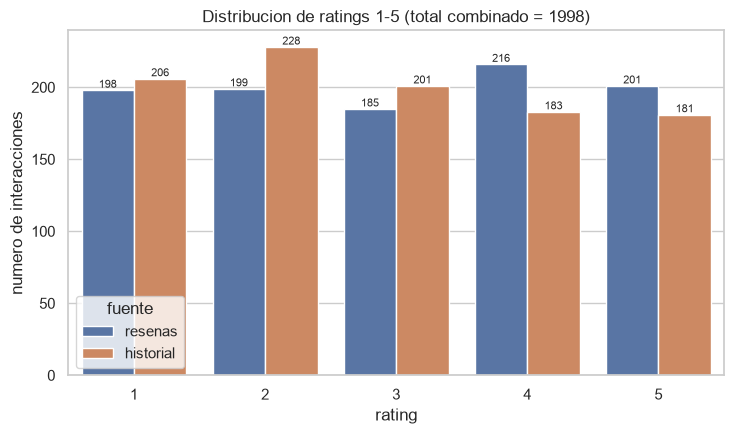

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
dist_plot = dist[["resenas", "historial"]].reset_index().melt(
    id_vars="rating", var_name="fuente", value_name="n"
)
sns.barplot(data=dist_plot, x="rating", y="n", hue="fuente", ax=ax)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fontsize=8)
ax.set_title(f"Distribucion de ratings 1-5 (total combinado = {len(interacciones)})")
ax.set_xlabel("rating")
ax.set_ylabel("numero de interacciones")
fig.tight_layout()
fig.savefig(FIG_DIR / "distribucion_ratings.png", dpi=150)
plt.show()

## 3. Long-tail de interacciones por usuario

En sistemas recomendadores reales la mayoría de usuarios tienen pocas interacciones. Verificamos cuántas interacciones tiene cada usuario y qué tan acentuada es la cola larga; esto condiciona el *split* por usuario y las métricas de ranking.

Estadisticas de interacciones por usuario:
count    858.00
mean       2.33
std        1.24
min        1.00
25%        1.00
50%        2.00
75%        3.00
max        7.00

Usuarios con 1 sola interaccion: 252 (29.4 % de los usuarios con interacciones)
Usuarios con <= 2 interacciones: 532 (62.0 %)


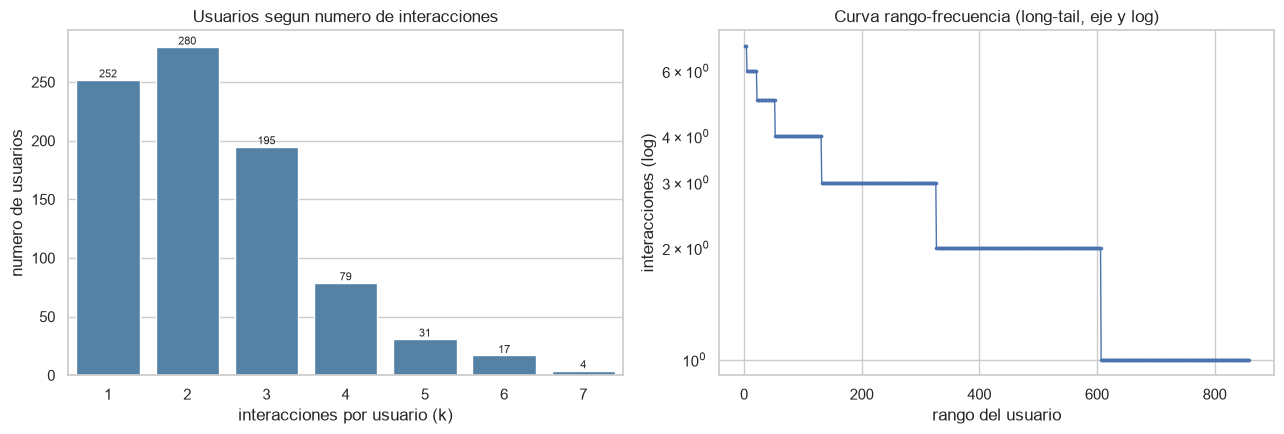

In [9]:
por_usuario = interacciones.groupby("UserID").size()

print("Estadisticas de interacciones por usuario:")
print(por_usuario.describe().round(2).to_string())
print(f"\nUsuarios con 1 sola interaccion: {(por_usuario == 1).sum()} "
      f"({(por_usuario == 1).mean() * 100:.1f} % de los usuarios con interacciones)")
print(f"Usuarios con <= 2 interacciones: {(por_usuario <= 2).sum()} "
      f"({(por_usuario <= 2).mean() * 100:.1f} %)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

conteo_k = por_usuario.value_counts().sort_index()
sns.barplot(x=conteo_k.index, y=conteo_k.values, color="steelblue", ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fontsize=8)
axes[0].set_title("Usuarios segun numero de interacciones")
axes[0].set_xlabel("interacciones por usuario (k)")
axes[0].set_ylabel("numero de usuarios")

ordenado = np.sort(por_usuario.values)[::-1]
axes[1].plot(np.arange(1, len(ordenado) + 1), ordenado, marker=".", markersize=3, linewidth=1)
axes[1].set_yscale("log")
axes[1].set_title("Curva rango-frecuencia (long-tail, eje y log)")
axes[1].set_xlabel("rango del usuario")
axes[1].set_ylabel("interacciones (log)")

fig.tight_layout()
fig.savefig(FIG_DIR / "long_tail_usuarios.png", dpi=150)
plt.show()

## 4. Popularidad de destinos (top-10)

Del lado de los ítems miramos cuántas interacciones acumula cada destino. Cruzamos con el catálogo para mostrar nombre, tipo y estado.

Estadisticas de interacciones por destino:
count    866.00
mean       2.31
std        1.24
min        1.00
25%        1.00
50%        2.00
75%        3.00
max        7.00


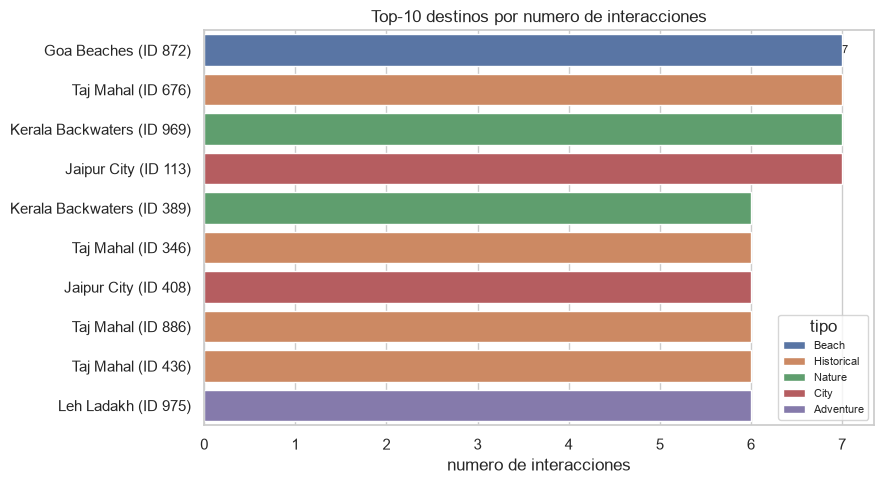

,DestinationID,n_interacciones,Name,Type,State
0,872,7,Goa Beaches,Beach,Goa
1,676,7,Taj Mahal,Historical,Uttar Pradesh
2,969,7,Kerala Backwaters,Nature,Kerala
3,113,7,Jaipur City,City,Rajasthan
4,389,6,Kerala Backwaters,Nature,Kerala
5,346,6,Taj Mahal,Historical,Uttar Pradesh
6,408,6,Jaipur City,City,Rajasthan
7,886,6,Taj Mahal,Historical,Uttar Pradesh
8,436,6,Taj Mahal,Historical,Uttar Pradesh
9,975,6,Leh Ladakh,Adventure,Jammu and Kashmir


In [10]:
por_destino = interacciones.groupby("DestinationID").size().sort_values(ascending=False)
top10 = (
    por_destino.head(10)
    .rename("n_interacciones")
    .to_frame()
    .join(destinos.set_index("DestinationID")[["Name", "Type", "State"]])
    .reset_index()
)

print("Estadisticas de interacciones por destino:")
print(por_destino.describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
top10_plot = top10.copy()
top10_plot["etiqueta"] = top10_plot["Name"] + " (ID " + top10_plot["DestinationID"].astype(str) + ")"
sns.barplot(data=top10_plot, y="etiqueta", x="n_interacciones", hue="Type", dodge=False, ax=ax)
ax.bar_label(ax.containers[0], fontsize=8)
ax.set_title("Top-10 destinos por numero de interacciones")
ax.set_xlabel("numero de interacciones")
ax.set_ylabel("")
ax.legend(title="tipo", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "popularidad_destinos.png", dpi=150)
plt.show()

top10

## 5. Sparsidad de la matriz usuario–destino

La sparsidad (proporción de celdas vacías de la matriz usuario × destino) es el indicador clave de filtrado colaborativo: cuanto más cerca de 1, menos señal hay para aprender similitudes usuario–usuario o ítem–ítem, y más importante se vuelve el componente de contenido del modelo híbrido.

In [11]:
n_celdas = n_users_inter * n_items_inter
densidad = n_pares_unicos / n_celdas
sparsidad = 1 - densidad

print(f"Usuarios con interacciones:    {n_users_inter}")
print(f"Destinos con interacciones:    {n_items_inter}")
print(f"Celdas posibles de la matriz:  {n_celdas:,}")
print(f"Celdas ocupadas (pares unicos): {n_pares_unicos:,}")
print(f"Densidad:  {densidad:.6f} ({densidad * 100:.3f} %)")
print(f"Sparsidad: {sparsidad:.6f} ({sparsidad * 100:.3f} %)")

Usuarios con interacciones:    858
Destinos con interacciones:    866
Celdas posibles de la matriz:  743,028
Celdas ocupadas (pares unicos): 1,998
Densidad:  0.002689 (0.269 %)
Sparsidad: 0.997311 (99.731 %)


## 6. Análisis de contenido del catálogo

Columnas de contenido de `Expanded_Destinations.csv` (`Type`, `State`, `BestTimeToVisit`, `Popularity`) y preferencias declaradas por los usuarios: son las variables que alimentan el vector de características de ítem del modelo híbrido.

In [12]:
print("=== Tipo de destino (Type) ===")
print(destinos["Type"].value_counts().to_string())

print("\n=== Estado (State) ===")
print(destinos["State"].value_counts().to_string())

print("\n=== Mejor epoca para visitar (BestTimeToVisit) ===")
print(destinos["BestTimeToVisit"].value_counts().to_string())

print("\n=== Popularidad (score del catalogo) ===")
print(destinos["Popularity"].describe().round(3).to_string())

preferencias = usuarios["Preferences"].fillna("").str.split(",").explode().str.strip()
preferencias = preferencias[preferencias != ""]
print("\n=== Preferencias declaradas por los usuarios ===")
print(preferencias.value_counts().to_string())

print("\n=== Genero de los usuarios ===")
print(usuarios["Gender"].value_counts().to_string())

=== Tipo de destino (Type) ===
Type
Historical    200
Beach         200
City          200
Nature        200
Adventure     200

=== Estado (State) ===
State
Uttar Pradesh        200
Goa                  200
Rajasthan            200
Kerala               200
Jammu and Kashmir    200

=== Mejor epoca para visitar (BestTimeToVisit) ===
BestTimeToVisit
Nov-Feb    200
Nov-Mar    200
Oct-Mar    200
Sep-Mar    200
Apr-Jun    200

=== Popularidad (score del catalogo) ===
count    1000.000
mean        8.514
std         0.567
min         7.504
25%         8.034
50%         8.497
75%         9.021
max         9.500

=== Preferencias declaradas por los usuarios ===
Preferences
Historical    666
Beaches       333
Nature        333
Adventure     333
City          333

=== Genero de los usuarios ===
Gender
Male      503
Female    496


## 7. DestinationIDs duplicados para un mismo lugar

Un hallazgo importante de este dataset: el catálogo tiene 1.000 `DestinationID` únicos, pero **muy pocos nombres de lugar distintos**. Verificamos cuántos nombres únicos existen y cuántos IDs distintos apuntan al mismo lugar. Esto confirma que la unidad de recomendación es el `DestinationID` (cada ID es un ítem independiente para el modelo), no el nombre del lugar.

In [13]:
ids_por_nombre = destinos.groupby("Name")["DestinationID"].nunique().sort_values(ascending=False)
print(f"DestinationID unicos en el catalogo: {destinos['DestinationID'].nunique()}")
print(f"Nombres de lugar unicos:             {destinos['Name'].nunique()}")
print(f"\nIDs distintos por nombre de lugar:")
print(ids_por_nombre.to_string())

ejemplo = destinos[destinos["Name"] == ids_por_nombre.index[0]].head(8)
print(f"\nEjemplo: varios DestinationID para '{ids_por_nombre.index[0]}' "
      f"(mismo Name, State y Type, distinto ID y Popularidad):")
ejemplo

DestinationID unicos en el catalogo: 1000
Nombres de lugar unicos:             5

IDs distintos por nombre de lugar:
Name
Goa Beaches          200
Jaipur City          200
Kerala Backwaters    200
Leh Ladakh           200
Taj Mahal            200

Ejemplo: varios DestinationID para 'Goa Beaches' (mismo Name, State y Type, distinto ID y Popularidad):


,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
1,2,Goa Beaches,Goa,Beach,8.605032,Nov-Mar
6,7,Goa Beaches,Goa,Beach,9.145068,Nov-Mar
11,12,Goa Beaches,Goa,Beach,8.084318,Nov-Mar
16,17,Goa Beaches,Goa,Beach,7.524150,Nov-Mar
21,22,Goa Beaches,Goa,Beach,7.745074,Nov-Mar
26,27,Goa Beaches,Goa,Beach,7.504500,Nov-Mar
31,32,Goa Beaches,Goa,Beach,7.806330,Nov-Mar
36,37,Goa Beaches,Goa,Beach,8.874758,Nov-Mar


## 8. Resumen exportable

Guardamos los números clave del EDA en `docs/figures/module3_recommender/eda_summary.json` para trazabilidad.

In [14]:
summary = {
    "dataset": "Travel destination recommender (Kaggle)",
    "ruta_datos": "data/raw/module3_recommender",
    "archivos": [
        "Expanded_Destinations.csv",
        "Final_Updated_Expanded_Reviews.csv",
        "Final_Updated_Expanded_UserHistory.csv",
        "Final_Updated_Expanded_Users.csv",
    ],
    "n_usuarios_registrados": int(n_usuarios_reg),
    "n_destinos_catalogo": int(n_destinos_cat),
    "n_resenas": int(len(reviews)),
    "n_historial": int(len(historial)),
    "n_interacciones": int(len(interacciones)),
    "n_pares_usuario_destino_unicos": int(n_pares_unicos),
    "n_usuarios_con_interacciones": int(n_users_inter),
    "n_destinos_con_interacciones": int(n_items_inter),
    "usuarios_sin_interacciones": int(n_usuarios_reg - n_users_inter),
    "destinos_sin_interacciones": int(n_destinos_cat - n_items_inter),
    "distribucion_ratings": {
        "resenas": {str(k): int(v) for k, v in dist["resenas"].items()},
        "historial": {str(k): int(v) for k, v in dist["historial"].items()},
        "total_combinado": {str(k): int(v) for k, v in dist["total_combinado"].items()},
    },
    "rating_medio": round(float(interacciones["rating"].mean()), 3),
    "rating_mediana": float(interacciones["rating"].median()),
    "interacciones_por_usuario": {
        "min": int(por_usuario.min()),
        "max": int(por_usuario.max()),
        "media": round(float(por_usuario.mean()), 3),
        "mediana": float(por_usuario.median()),
        "usuarios_con_1_interaccion": int((por_usuario == 1).sum()),
        "usuarios_con_hasta_2_interacciones": int((por_usuario <= 2).sum()),
    },
    "sparsidad": round(sparsidad, 6),
    "densidad": round(densidad, 6),
    "top10_destinos": [
        {
            "destination_id": int(r.DestinationID),
            "nombre": r.Name,
            "tipo": r.Type,
            "estado": r.State,
            "n_interacciones": int(r.n_interacciones),
        }
        for r in top10.itertuples()
    ],
    "tipos_destino": {k: int(v) for k, v in destinos["Type"].value_counts().items()},
    "estados": {k: int(v) for k, v in destinos["State"].value_counts().items()},
    "preferencias_usuarios": {k: int(v) for k, v in preferencias.value_counts().items()},
    "nombres_lugar_unicos": int(destinos["Name"].nunique()),
    "ids_por_nombre": {k: int(v) for k, v in ids_por_nombre.items()},
    "figuras": [
        "distribucion_ratings.png",
        "long_tail_usuarios.png",
        "popularidad_destinos.png",
    ],
}

ruta_json = FIG_DIR / "eda_summary.json"
with open(ruta_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"Resumen guardado en: {ruta_json}")
print(json.dumps(summary, indent=2, ensure_ascii=False))

Resumen guardado en: D:\UNAL\2026-1S\Redes Neuronales y Alg. Bio\rna-sistema_de_transporte_inteligente\docs\figures\module3_recommender\eda_summary.json
{
  "dataset": "Travel destination recommender (Kaggle)",
  "ruta_datos": "data/raw/module3_recommender",
  "archivos": [
    "Expanded_Destinations.csv",
    "Final_Updated_Expanded_Reviews.csv",
    "Final_Updated_Expanded_UserHistory.csv",
    "Final_Updated_Expanded_Users.csv"
  ],
  "n_usuarios_registrados": 999,
  "n_destinos_catalogo": 1000,
  "n_resenas": 999,
  "n_historial": 999,
  "n_interacciones": 1998,
  "n_pares_usuario_destino_unicos": 1998,
  "n_usuarios_con_interacciones": 858,
  "n_destinos_con_interacciones": 866,
  "usuarios_sin_interacciones": 141,
  "destinos_sin_interacciones": 134,
  "distribucion_ratings": {
    "resenas": {
      "1": 198,
      "2": 199,
      "3": 185,
      "4": 216,
      "5": 201
    },
    "historial": {
      "1": 206,
      "2": 228,
      "3": 201,
      "4": 183,
      "5": 181
    

## Hallazgos principales

1. **Tamaño:** 999 usuarios registrados, 1.000 destinos en catálogo y **1.998 interacciones** (999 reseñas + 999 visitas del historial), todas como pares (usuario, destino) únicos.
2. **Cobertura:** solo **858 usuarios (85,9 %)** tienen al menos una interacción —141 usuarios registrados no tienen ninguna— y **134 destinos del catálogo (13,4 %)** no recibieron ninguna interacción (arranque en frío de ítems).
3. **Ratings casi uniformes:** la distribución 1–5 es prácticamente plana (entre 382 y 427 interacciones por valor; media ≈ 2,96, mediana = 3). No hay sesgo hacia ratings altos; con el criterio del pipeline (positivo = rating ≥ mediana), quedan ≈ 1.167 interacciones positivas.
4. **Long-tail marcado:** la media es de **2,33 interacciones por usuario** (mínimo 1, máximo 7); **252 usuarios (29,4 %) tienen una sola interacción** y el 62 % tiene ≤ 2. El *split* por usuario y la evaluación de ranking deben tolerar historiales muy cortos.
5. **Popularidad débil de ítems:** el destino más interactuado acumula apenas **7 interacciones** (IDs 872, 676, 969 y 113); la señal de popularidad es tenue y no basta por sí sola para recomendar.
6. **Sparsidad = 99,73 %:** de las 743.028 celdas posibles de la matriz usuario–destino solo 1.998 están ocupadas. Esta dispersión extrema justifica el enfoque **híbrido** (contenido + filtrado colaborativo) del módulo.
7. **Contenido totalmente balanceado:** 5 tipos de destino × 200 (`Historical`, `Beach`, `City`, `Nature`, `Adventure`), 5 estados × 200 y 5 épocas recomendadas × 200; la popularidad del catálogo es un score continuo entre 7,5 y 9,5.
8. **DestinationIDs duplicados para el mismo lugar:** el catálogo tiene 1.000 IDs pero **solo 5 nombres de lugar únicos** (`Taj Mahal`, `Goa Beaches`, `Kerala Backwaters`, `Jaipur City`, `Leh Ladakh`), cada uno repetido con **200 DestinationIDs distintos** (mismo nombre, estado y tipo; distinta popularidad). El modelo trata cada ID como ítem independiente; para interpretar resultados hay que agrupar por nombre.